# Martingale optimal transport from centered kernels

This notebook generates `fig:martingale-ot-centered-kernels`.  It constructs a feasible one-dimensional martingale coupling by applying space-varying centered kernels to a source Gaussian mixture, and then solves the finite-dimensional martingale optimal transport linear program with the same marginals.

The martingale constraint is

$$
    \sum_j (y_j-x_i) P_{ij}=0 \qquad \text{for every source grid point }x_i,
$$

so the barycentric projection of the coupling is the identity.  The generated kernel coupling is useful as a feasibility certificate, while the optimized coupling shows the sparse geometry selected by an actual martingale OT objective.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy.optimize import linprog
from scipy import sparse

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "martingale-ot-centered-kernels"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)


## Discrete source, centered kernels, and martingale LP

The source is a smooth one-dimensional Gaussian mixture on a grid.  For each grid point `x[i]`, the row `K[i, :]` is a symmetric discrete kernel, hence its barycenter is exactly `x[i]`.  The target marginal is then generated as `b = a K`.  This gives one feasible martingale coupling `P_gen = diag(a) K`.

To display an actual martingale optimal transport solution, we solve a linear program with prescribed row sums, prescribed column sums, and the martingale row constraints above.  The objective used here is the mean absolute displacement; it is chosen only to select a readable sparse martingale plan among the feasible plans.


In [2]:
N = 75
x = np.linspace(-3.35, 3.35, N)
dx = x[1] - x[0]


def gaussian(mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)


alpha_density = (
    0.54 * gaussian(-1.20, 0.24)
    + 0.31 * gaussian(0.10, 0.31)
    + 0.15 * gaussian(1.36, 0.20)
)
a = alpha_density * dx
a = a / a.sum()
alpha_density = a / dx

K = np.zeros((N, N))
sigmas = 0.15 + 0.34 * (0.5 + 0.5 * np.sin(1.20 * x - 0.20)) + 0.19 * np.exp(-0.5 * ((x - 0.55) / 0.66) ** 2)

for i, sigma in enumerate(sigmas):
    # Symmetric truncation keeps the conditional mean exactly at x[i].
    max_radius = min(i, N - 1 - i)
    radius = min(max_radius, max(2, int(np.ceil(3.15 * sigma / dx))))
    offsets = np.arange(-radius, radius + 1)
    weights = np.exp(-0.5 * ((offsets * dx) / sigma) ** 2)
    weights = weights / weights.sum()
    K[i, i + offsets] = weights

P_gen = a[:, None] * K
b = P_gen.sum(axis=0)
beta_density = b / dx

def row_barycenter(P):
    row_masses = P.sum(axis=1)
    return (P @ x) / np.maximum(row_masses, 1e-300)

row_bary_gen = row_barycenter(P_gen)

assert np.allclose(P_gen.sum(axis=1), a, atol=1e-14)
assert np.allclose(P_gen.sum(axis=0), b, atol=1e-14)
assert abs(P_gen.sum() - 1.0) < 1e-14
assert np.max(np.abs(row_bary_gen[a > 1e-12] - x[a > 1e-12])) < 2e-12
assert abs(np.dot(a, x) - np.dot(b, x)) < 2e-14

# A one-dimensional convex-order diagnostic: all call functions increase.
call_alpha = np.array([np.sum(np.maximum(x - t, 0.0) * a) for t in x])
call_beta = np.array([np.sum(np.maximum(x - t, 0.0) * b) for t in x])
assert np.min(call_beta - call_alpha) > -2e-12


def solve_martingale_lp(a, b):
    n = len(a)
    rows = []
    cols = []
    vals = []
    rhs = []
    row_id = 0

    # Row constraints.
    for i in range(n):
        for j in range(n):
            rows.append(row_id); cols.append(i * n + j); vals.append(1.0)
        rhs.append(a[i]); row_id += 1

    # Column constraints.
    for j in range(n):
        for i in range(n):
            rows.append(row_id); cols.append(i * n + j); vals.append(1.0)
        rhs.append(b[j]); row_id += 1

    # Martingale constraints: E[Y-X | X=x_i] times row mass equals zero.
    for i in range(n):
        for j in range(n):
            rows.append(row_id); cols.append(i * n + j); vals.append(x[j] - x[i])
        rhs.append(0.0); row_id += 1

    Aeq = sparse.coo_matrix((vals, (rows, cols)), shape=(row_id, n * n)).tocsr()
    beq = np.asarray(rhs)
    X, Y = np.meshgrid(x, x, indexing="ij")
    cost = np.abs(Y - X).ravel()
    res = linprog(cost, A_eq=Aeq, b_eq=beq, bounds=(0, None), method="highs")
    if not res.success:
        raise RuntimeError(res.message)
    return res.x.reshape(n, n)


P_opt = solve_martingale_lp(a, b)
row_bary_opt = row_barycenter(P_opt)
print(f"LP nonzeros above 1e-9: {np.sum(P_opt > 1e-9)}")
print(f"generated mean |Y-X|: {np.sum(P_gen * np.abs(x[None, :] - x[:, None])):.4f}")
print(f"optimized mean |Y-X|: {np.sum(P_opt * np.abs(x[None, :] - x[:, None])):.4f}")
print(f"max martingale residual: {np.max(np.abs(row_bary_opt[a > 1e-11] - x[a > 1e-11])):.2e}")


LP nonzeros above 1e-9: 145
generated mean |Y-X|: 0.2482
optimized mean |Y-X|: 0.1057
max martingale residual: 9.05e-02


## Exported panels

The manuscript arranges the panels in LaTeX, so the individual PDF files contain no embedded titles.  The two central panels contrast the feasible coupling used to generate the target marginal and the optimized martingale coupling obtained by linear programming.


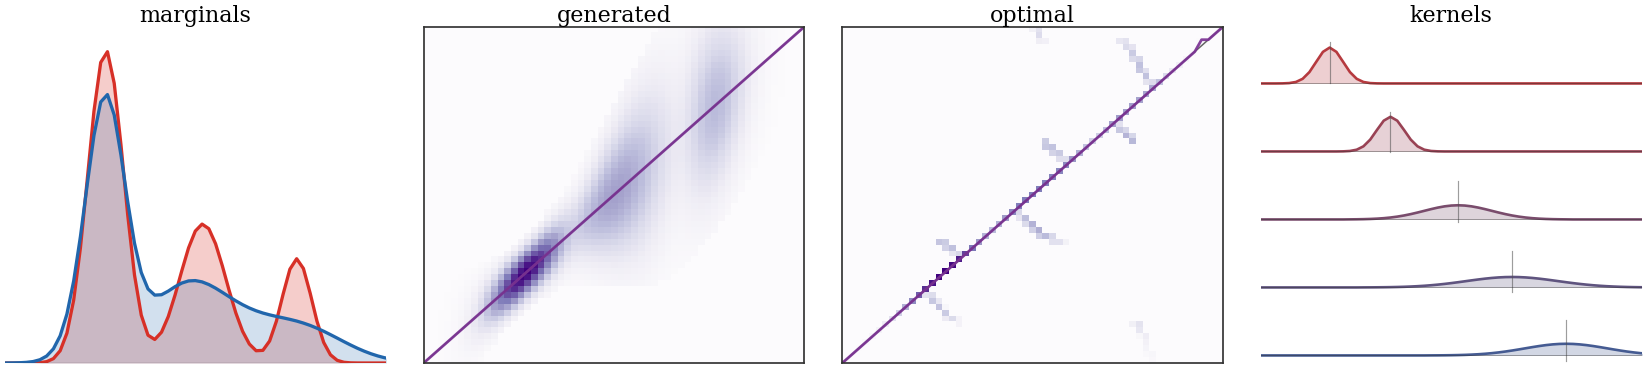

In [3]:
XLIM = (-2.55, 2.55)
DENSITY_YMAX = 1.08 * max(alpha_density.max(), beta_density.max())


def draw_marginals(ax):
    ax.fill_between(x, 0, alpha_density, color=RED, alpha=0.24, linewidth=0)
    ax.plot(x, alpha_density, color=RED, lw=1.18, solid_capstyle="round")
    ax.fill_between(x, 0, beta_density, color=BLUE, alpha=0.20, linewidth=0)
    ax.plot(x, beta_density, color=BLUE, lw=1.18, solid_capstyle="round")
    ax.axhline(0, color="#303030", lw=0.42)
    ax.set_xlim(*XLIM)
    ax.set_ylim(0, DENSITY_YMAX)
    remove_axes(ax)


def normalized_coupling_image(P):
    M = P.T
    return np.power(M / max(M.max(), 1e-300), 0.40)


def draw_coupling(ax, P, row_bary, *, cmap="Purples"):
    img = normalized_coupling_image(P)
    ax.imshow(
        img,
        origin="lower",
        extent=[x[0], x[-1], x[0], x[-1]],
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=1,
        aspect="auto",
    )
    ax.plot(XLIM, XLIM, color="#2b2b2b", lw=0.55, alpha=0.72)
    ax.plot(x, row_bary, color=VIOLET, lw=1.00, alpha=0.92)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*XLIM)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.62)
        spine.set_color("#333333")


def draw_conditionals(ax):
    selected_locations = np.array([-1.65, -0.80, 0.10, 0.85, 1.55])
    selected = [int(np.argmin(np.abs(x - t))) for t in selected_locations]
    bases = np.linspace(len(selected) - 1, 0, len(selected)) * 0.36
    scale = 0.19 / (K[selected].max() / dx)
    for rank, i in enumerate(selected):
        t = (x[i] - XLIM[0]) / (XLIM[1] - XLIM[0])
        color = interp_color(float(np.clip(t, 0, 1)), RED, BLUE)
        density = K[i] / dx
        base = bases[rank]
        ax.fill_between(x, base, base + scale * density, color=color, alpha=0.24, linewidth=0)
        ax.plot(x, base + scale * density, color=color, lw=0.95, solid_capstyle="round")
        ax.axvline(x[i], ymin=(base + 0.01) / (bases[0] + 0.30), ymax=(base + 0.22) / (bases[0] + 0.30), color=GRAY, lw=0.42, alpha=0.55)
        ax.axhline(base, color="#303030", lw=0.32, alpha=0.45)
    ax.set_xlim(*XLIM)
    ax.set_ylim(-0.04, bases[0] + 0.30)
    remove_axes(ax)


# Individual PDF panels.
panels = {
    "marginals.pdf": lambda ax: draw_marginals(ax),
    "generated-coupling.pdf": lambda ax: draw_coupling(ax, P_gen, row_bary_gen, cmap="Purples"),
    "optimal-coupling.pdf": lambda ax: draw_coupling(ax, P_opt, row_bary_opt, cmap="Purples"),
    "conditionals.pdf": lambda ax: draw_conditionals(ax),
}

for filename, drawer in panels.items():
    fig, ax = plt.subplots(figsize=(2.18, 1.82))
    drawer(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.02 if filename != "optimal-coupling.pdf" else 0.025)
    plt.close(fig)
    import shutil
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")

# Backward-compatible alias until all generated PDFs in old builds disappear.
import shutil
shutil.copy2(OUT / "generated-coupling.pdf", OUT / "coupling.pdf")
shutil.copy2(OUT / "generated-coupling.pdf", ARXIV_OUT / f"{NAME}--coupling.pdf")

# Notebook thumbnail with compact panel labels for the gallery only.
fig, axes = plt.subplots(1, 4, figsize=(8.35, 2.05))
for ax, title, drawer in zip(axes, ["marginals", "generated", "optimal", "kernels"], panels.values()):
    drawer(ax)
    ax.set_title(title, fontsize=8, pad=1)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.84, wspace=0.10)
fig.savefig(THUMB, dpi=200, bbox_inches="tight", pad_inches=0.025)
plt.close(fig)
display(Image(filename=str(THUMB)))


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

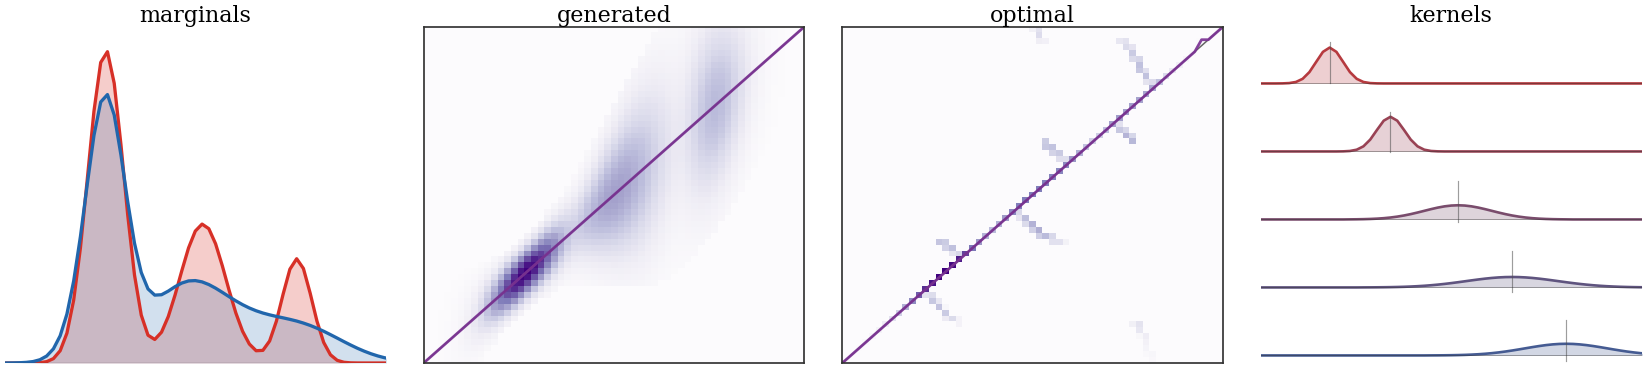

In [4]:
_thumb = FIGROOT / "thumbnails" / "martingale-ot-centered-kernels.png"
display(Image(filename=str(_thumb)))
